# Apple Inc. (AAPL) Historical Stock Analysis

## Advanced Python for Data Analysis

### AnalystLab Africa Internship – Week 6

**Dataset:** Apple Inc. (AAPL) Historical Stock Prices (Yahoo Finance)

**Objective:**
To apply advanced Python techniques for data transformation, time-series analysis, and feature engineering in order to uncover trends and generate meaningful insights from Apple's historical stock market data.

---

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib

---

## Business Understanding

Stock market data contains valuable information about market performance and investor behaviour.

This project explores Apple's historical stock prices over the last five years using advanced Python techniques including data transformation, time-series analysis, and feature engineering to uncover trends and generate actionable insights.

## Project Objectives

This project aims to:

- Load and explore Apple's historical stock price data.
- Clean and preprocess the dataset.
- Perform advanced data transformation using Pandas.
- Conduct time-series analysis to identify trends and patterns.
- Engineer new financial features for deeper analysis.
- Create meaningful visualizations to communicate findings.
- Generate actionable insights from the analysis.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

%matplotlib inline
plt.style.use("ggplot")

In [14]:
df = yf.download(
    "AAPL",
    period="5y",
    auto_adjust=False,
    progress=False
)

df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2021-07-12,140.851669,144.500000,146.320007,144.000000,146.210007,76299700
2021-07-13,141.962845,145.639999,147.460007,143.630005,144.029999,100827100
2021-07-14,145.384247,149.149994,149.570007,147.679993,148.100006,127050800
2021-07-15,144.731186,148.479996,150.000000,147.089996,149.240005,106820300
2021-07-16,142.693954,146.389999,149.759995,145.880005,148.460007,93251400


In [15]:
# Convert the Index into a Column
df = df.reset_index()

df.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
0,2021-07-12,140.851669,144.500000,146.320007,144.000000,146.210007,76299700
1,2021-07-13,141.962845,145.639999,147.460007,143.630005,144.029999,100827100
2,2021-07-14,145.384247,149.149994,149.570007,147.679993,148.100006,127050800
3,2021-07-15,144.731186,148.479996,150.000000,147.089996,149.240005,106820300
4,2021-07-16,142.693954,146.389999,149.759995,145.880005,148.460007,93251400


In [16]:
# Keep only the first level of the column names
df.columns = df.columns.get_level_values(0)

df.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume
0,2021-07-12,140.851669,144.500000,146.320007,144.000000,146.210007,76299700
1,2021-07-13,141.962845,145.639999,147.460007,143.630005,144.029999,100827100
2,2021-07-14,145.384247,149.149994,149.570007,147.679993,148.100006,127050800
3,2021-07-15,144.731186,148.479996,150.000000,147.089996,149.240005,106820300
4,2021-07-16,142.693954,146.389999,149.759995,145.880005,148.460007,93251400


In [17]:
df.columns

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [18]:
df.to_csv("AAPL.csv", index=False)

In [27]:
# Reload the CSV
df = pd.read_csv("AAPL.csv")

df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2021-07-12,140.851669,144.500000,146.320007,144.000000,146.210007,76299700
1,2021-07-13,141.962845,145.639999,147.460007,143.630005,144.029999,100827100
2,2021-07-14,145.384247,149.149994,149.570007,147.679993,148.100006,127050800
3,2021-07-15,144.731186,148.479996,150.000000,147.089996,149.240005,106820300
4,2021-07-16,142.693954,146.389999,149.759995,145.880005,148.460007,93251400


In [28]:
# Dataset Overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1255 non-null   object 
 1   Adj Close  1255 non-null   float64
 2   Close      1255 non-null   float64
 3   High       1255 non-null   float64
 4   Low        1255 non-null   float64
 5   Open       1255 non-null   float64
 6   Volume     1255 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 68.8+ KB


## Data Cleaning and Preprocessing

Data cleaning ensures that the dataset is complete, accurate, and ready for analysis. In this section, the dataset is inspected for missing values, duplicate records, and correct data types before performing advanced data transformation and time-series analysis.

In [29]:
# Convert Date
df["Date"] = pd.to_datetime(df["Date"])

In [30]:
df.isnull().sum()

Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,1255,2024-01-07 11:20:24.860557824,2021-07-12 00:00:00,2022-10-06 12:00:00,2024-01-08 00:00:00,2025-04-08 12:00:00,2026-07-10 00:00:00,NaN
Adj Close,1255.0,194.631137,122.933556,157.093864,183.438339,226.872566,316.220001,45.416275
Close,1255.0,196.606462,125.019997,160.245003,185.559998,228.400002,316.220001,44.518278
High,1255.0,198.572431,127.769997,162.440002,187.050003,230.459999,317.399994,44.882622
Low,1255.0,194.471745,124.169998,158.074997,183.619995,226.389999,312.170013,44.140573
Open,1255.0,196.411203,126.010002,160.150002,185.440002,228.580002,315.290009,44.493877
Volume,1255.0,65084442.319522,15367011.0,45731700.0,56934900.0,77101050.0,318679900.0,28698244.523734


## Data Transformation with Pandas

Data transformation involves creating new variables and restructuring the dataset to improve analysis. These derived features provide additional insights into stock price movements and prepare the data for time-series analysis.

In [34]:
# Calculate daily price change
df["Daily Price Change"] = df["Close"] - df["Open"]

df[["Date", "Open", "Close", "Daily Price Change"]].head()

,Date,Open,Close,Daily Price Change
0,2021-07-12,146.210007,144.500000,-1.710007
1,2021-07-13,144.029999,145.639999,1.610001
2,2021-07-14,148.100006,149.149994,1.049988
3,2021-07-15,149.240005,148.479996,-0.760010
4,2021-07-16,148.460007,146.389999,-2.070007


In [35]:
# Calculate daily percentage price change
df["Percentage Price Change"] = (
    (df["Close"] - df["Open"]) / df["Open"]
) * 100

df[["Date", "Percentage Price Change"]].head()

,Date,Percentage Price Change
0,2021-07-12,-1.169555
1,2021-07-13,1.117823
2,2021-07-14,0.708972
3,2021-07-15,-0.509253
4,2021-07-16,-1.394320


In [36]:
# Daily trading range
df["High-Low Difference"] = df["High"] - df["Low"]

df[["Date", "High-Low Difference"]].head()

,Date,High-Low Difference
0,2021-07-12,2.320007
1,2021-07-13,3.830002
2,2021-07-14,1.890015
3,2021-07-15,2.910004
4,2021-07-16,3.879990


In [38]:
# Extract year
df["Year"] = df["Date"].dt.year

In [39]:
# Extract month
df["Month"] = df["Date"].dt.month_name()

In [40]:
# Extract day name
df["Day"] = df["Date"].dt.day_name()

### Data Transformation Summary

Several new features were created from the original dataset to support further analysis. These include daily price change, percentage price change, high-low trading range, and date-based features such as year, month, and day of the week. These transformed variables provide deeper insights into Apple's stock performance over time.

## Time-Series Analysis

Time-series analysis examines how Apple's stock performance changed over time. By visualizing trends, trading activity, and price movements, we can identify patterns, seasonality, and market behaviour across the five-year period.

### Visualization 1 — Closing Price Trend

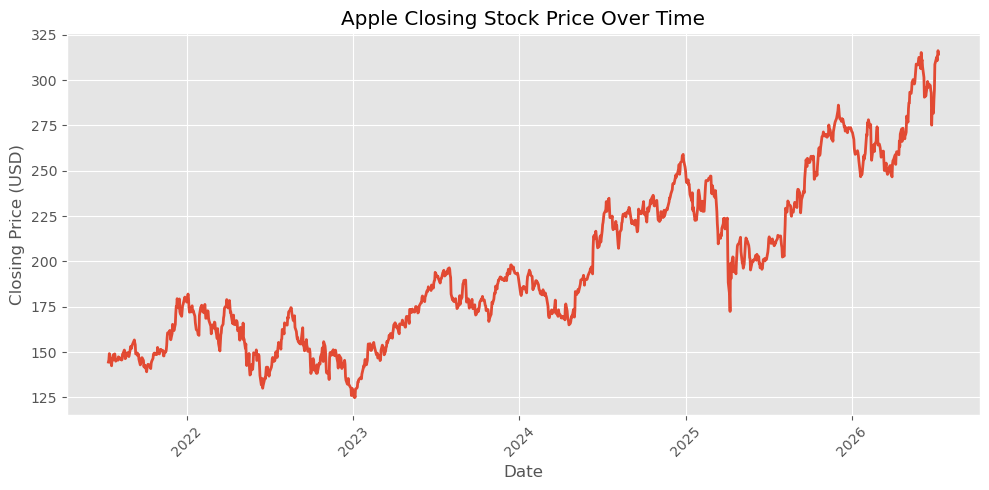

In [69]:
plt.figure(figsize=(10,5))

plt.plot(df["Date"], df["Close"], linewidth=2)

plt.title("Apple Closing Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The line chart illustrates the movement of Apple's closing stock price over the five-year period. Overall, the stock demonstrates an upward long-term trend, although several periods of market fluctuations are visible. These fluctuations reflect changing market conditions while the overall growth indicates strong long-term performance.

## Visualization 2 — Trading Volume Trend

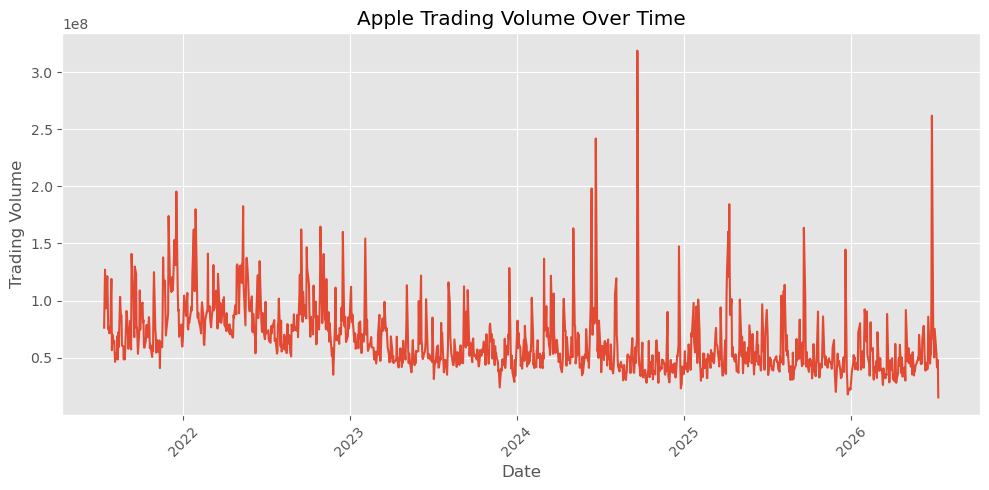

In [43]:
plt.figure(figsize=(10,5))

plt.plot(df["Date"], df["Volume"], linewidth=1.5)

plt.title("Apple Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Trading Volume")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The trading volume chart highlights changes in the number of shares traded over time. Noticeable spikes indicate periods of increased investor activity, which often coincide with major company announcements or significant market events.

## Feature Engineering

Feature engineering involves creating new variables from existing data to improve analysis. These derived features help reveal market trends, price movements, volatility, and investment patterns that are not immediately visible from the raw dataset.

In [44]:
df["Daily Price Change"] = df["Close"] - df["Open"]

df[["Date", "Open", "Close", "Daily Price Change"]].head()

,Date,Open,Close,Daily Price Change
0,2021-07-12,146.210007,144.500000,-1.710007
1,2021-07-13,144.029999,145.639999,1.610001
2,2021-07-14,148.100006,149.149994,1.049988
3,2021-07-15,149.240005,148.479996,-0.760010
4,2021-07-16,148.460007,146.389999,-2.070007


In [45]:
# Daily Percentage Change

df["Daily % Change"] = (
    (df["Close"] - df["Open"]) / df["Open"]
) * 100

df[["Date", "Daily % Change"]].head()

,Date,Daily % Change
0,2021-07-12,-1.169555
1,2021-07-13,1.117823
2,2021-07-14,0.708972
3,2021-07-15,-0.509253
4,2021-07-16,-1.394320


In [46]:
# 7-Day Moving Average

df["MA_7"] = df["Close"].rolling(window=7).mean()

In [47]:
# 30-Day Moving Average

df["MA_30"] = df["Close"].rolling(window=30).mean()

In [48]:
# Daily Returns

df["Daily Return"] = df["Close"].pct_change()

In [49]:
# Monthly Returns

df["Month"] = df["Date"].dt.to_period("M")

monthly_returns = (
    df.groupby("Month")["Close"]
      .last()
      .pct_change() * 100
)

monthly_returns.head()

Month
2021-07          NaN
2021-08     4.092967
2021-09    -6.803663
2021-10     5.865727
2021-11    10.347129
Freq: M, Name: Close, dtype: float64

In [50]:
# Rolling Volatility (30 Days)

df["Volatility"] = (
    df["Daily Return"]
      .rolling(30)
      .std()
)

In [51]:
# Check New Features
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Daily Price Change,Percentage Price Change,High-Low Difference,Year,Month,Day,Daily % Change,MA_7,MA_30,Daily Return,Volatility
0,2021-07-12,140.851669,144.500000,146.320007,144.000000,146.210007,76299700,-1.710007,-1.169555,2.320007,2021,2021-07,Monday,-1.169555,NaN,NaN,NaN,NaN
1,2021-07-13,141.962845,145.639999,147.460007,143.630005,144.029999,100827100,1.610001,1.117823,3.830002,2021,2021-07,Tuesday,1.117823,NaN,NaN,0.007889,NaN
2,2021-07-14,145.384247,149.149994,149.570007,147.679993,148.100006,127050800,1.049988,0.708972,1.890015,2021,2021-07,Wednesday,0.708972,NaN,NaN,0.024100,NaN
3,2021-07-15,144.731186,148.479996,150.000000,147.089996,149.240005,106820300,-0.760010,-0.509253,2.910004,2021,2021-07,Thursday,-0.509253,NaN,NaN,-0.004492,NaN
4,2021-07-16,142.693954,146.389999,149.759995,145.880005,148.460007,93251400,-2.070007,-1.394320,3.879990,2021,2021-07,Friday,-1.394320,NaN,NaN,-0.014076,NaN


In [52]:
df[["MA_7", "MA_30", "Daily Return", "Volatility"]].tail()

,MA_7,MA_30,Daily Return,Volatility
1250,292.242855,299.934667,0.013058,0.021194
1251,297.315713,300.123667,-0.006397,0.021188
1252,301.545715,300.276001,0.008788,0.021127
1253,306.471431,300.539001,0.009030,0.021176
1254,310.031433,300.653335,-0.006135,0.021172


### Moving Average Analysis

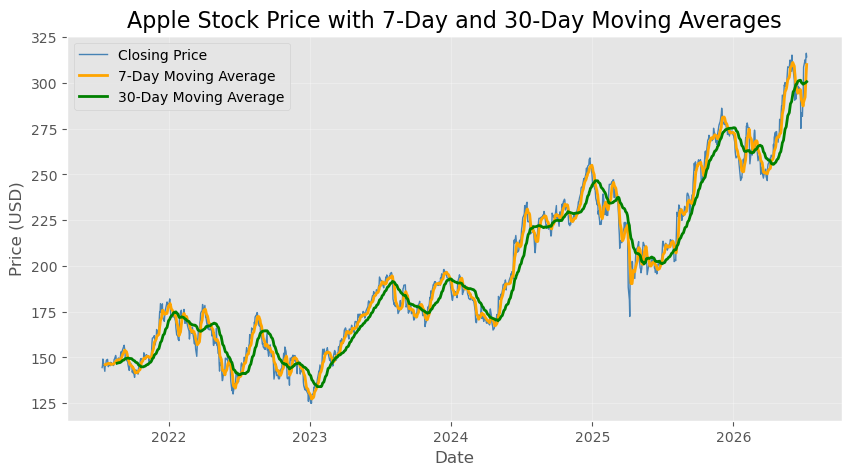

In [54]:
plt.figure(figsize=(10,5))

plt.plot(df["Date"], df["Close"], label="Closing Price", color="steelblue", linewidth=1)

plt.plot(df["Date"], df["MA_7"], label="7-Day Moving Average", color="orange", linewidth=2)

plt.plot(df["Date"], df["MA_30"], label="30-Day Moving Average", color="green", linewidth=2)

plt.title("Apple Stock Price with 7-Day and 30-Day Moving Averages", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [57]:
# Monthly average closing price
monthly_close = df.resample("ME", on="Date")["Close"].mean()


# Monthly percentage return
monthly_return = monthly_close.pct_change() * 100

monthly_return.head()

Date
2021-07-31         NaN
2021-08-31    1.225359
2021-09-30    0.086695
2021-10-31   -1.849135
2021-11-30    5.971201
Freq: ME, Name: Close, dtype: float64

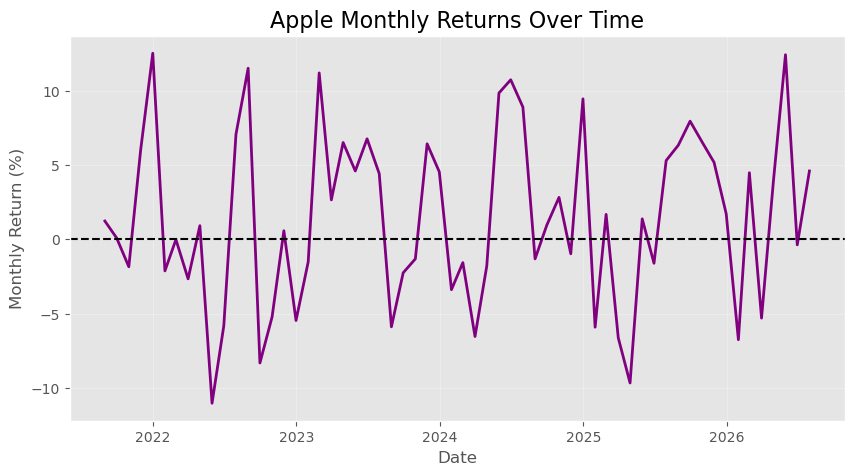

In [56]:
# Plot Monthly Returns

plt.figure(figsize=(10,5))

plt.plot(monthly_return.index,
         monthly_return.values,
         color="purple",
         linewidth=2)

plt.title("Apple Monthly Returns Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Monthly Return (%)")

plt.axhline(0, color="black", linestyle="--")

plt.grid(alpha=0.3)

plt.show()

In [60]:
# Summary statistics
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,1255,2024-01-07 11:20:24.860557824,2021-07-12 00:00:00,2022-10-06 12:00:00,2024-01-08 00:00:00,2025-04-08 12:00:00,2026-07-10 00:00:00,NaN
Adj Close,1255.0,194.631137,122.933556,157.093864,183.438339,226.872566,316.220001,45.416275
Close,1255.0,196.606462,125.019997,160.245003,185.559998,228.400002,316.220001,44.518278
High,1255.0,198.572431,127.769997,162.440002,187.050003,230.459999,317.399994,44.882622
Low,1255.0,194.471745,124.169998,158.074997,183.619995,226.389999,312.170013,44.140573
Open,1255.0,196.411203,126.010002,160.150002,185.440002,228.580002,315.290009,44.493877
Volume,1255.0,65084442.319522,15367011.0,45731700.0,56934900.0,77101050.0,318679900.0,28698244.523734
Daily Price Change,1255.0,0.195259,-14.279999,-1.289993,0.199997,1.669998,26.900009,2.883941
Percentage Price Change,1255.0,0.112897,-7.648634,-0.643407,0.098966,0.899406,15.644088,1.493431
High-Low Difference,1255.0,4.100686,0.959991,2.619995,3.539993,4.945,28.720001,2.332304


In [62]:
# Create professional summary table

summary_df = pd.DataFrame({
    "Metric": [
        "Highest Closing Price",
        "Lowest Closing Price",
        "Highest Trading Volume",
        "Best Daily Return (%)",
        "Worst Daily Return (%)",
        "Highest 30-Day Volatility"
    ],
    "Date": [
        df.loc[df["Close"].idxmax(), "Date"],
        df.loc[df["Close"].idxmin(), "Date"],
        df.loc[df["Volume"].idxmax(), "Date"],
        df.loc[df["Daily Return"].idxmax(), "Date"],
        df.loc[df["Daily Return"].idxmin(), "Date"],
        df.loc[df["Volatility"].idxmax(), "Date"]
    ],
    "Value": [
        round(df["Close"].max(), 2),
        round(df["Close"].min(), 2),
        f"{df['Volume'].max():,}",
        f"{df['Daily Return'].max()*100:.2f}%",
        f"{df['Daily Return'].min()*100:.2f}%",
        f"{df['Volatility'].max()*100:.2f}%"
    ]
})

summary_df

,Metric,Date,Value
0,Highest Closing Price,2026-07-09,316.22
1,Lowest Closing Price,2023-01-05,125.02
2,Highest Trading Volume,2024-09-20,"318,679,900"
3,Best Daily Return (%),2025-04-09,15.33%
4,Worst Daily Return (%),2025-04-03,-9.25%
5,Highest 30-Day Volatility,2025-05-12,4.40%


## Key Insights

The analysis of Apple's historical stock market data revealed several important trends regarding price movement, trading activity, and market performance over the past five years.

In [70]:
# Create a summary table of key findings

key_findings = pd.DataFrame({
    "Metric": [
        "Average Closing Price (USD)",
        "Average Trading Volume",
        "Average Daily Return (%)",
        "Average 30-Day Volatility (%)",
        "Overall Stock Growth (%)"
    ],
    "Value": [
        round(df["Close"].mean(), 2),
        f"{df['Volume'].mean():,.0f}",
        f"{df['Daily Return'].mean()*100:.2f}%",
        f"{df['Volatility'].mean()*100:.2f}%",
        f"{overall_growth:.2f}%"
    ]
})

key_findings

,Metric,Value
0,Average Closing Price (USD),196.61
1,Average Trading Volume,"65,084,442"
2,Average Daily Return (%),0.08%
3,Average 30-Day Volatility (%),1.64%
4,Overall Stock Growth (%),117.49%


## Key Findings

- Apple recorded an average closing stock price of **$196.61** during the five-year study period.

- The stock traded an average daily volume of approximately **65.1 million shares**, indicating consistently high market liquidity.

- The average daily return was **0.08%**, reflecting steady long-term appreciation despite short-term market fluctuations.

- The average 30-day rolling volatility was **1.64%**, suggesting moderate price variability over the analysis period.

- Overall, Apple's stock price increased by **117.49%** across the five-year period, demonstrating strong long-term growth and resilience.

## Conclusion

This project successfully applied advanced Python techniques to analyze five years of Apple Inc.'s historical stock market data. The analysis included data transformation, feature engineering, time-series analysis, and data visualization to uncover meaningful trends in stock performance.

The findings indicate that Apple experienced strong long-term growth, with its stock price increasing by approximately **117.49%** over the analysis period. While short-term fluctuations and periods of higher volatility were observed, the overall trend remained positive. The moving average analysis further confirmed sustained upward momentum, and the trading volume analysis highlighted periods of increased market activity.

Overall, this project demonstrates how Python, Pandas, and Matplotlib can be effectively used to transform financial data into actionable insights, supporting informed investment analysis and decision-making.